In [8]:
import sys
sys.path.append('../')
from joblib import Parallel, delayed
import numpy as np
import matplotlib.pyplot as plt
import scqubits as scq
import pytz
import qutip as qt
from datetime import datetime

In [2]:
truncation=10
EL        = 0.377 # GHz
EJ        = 6.013 # Soft Zero Pi (Gyenis)
EC_phi    = 1.142
EC_theta  = 0.092
E_CJ = 2 * EC_phi
E_C = 2./(1./EC_theta -1./EC_phi)
phi_grid = scq.Grid1d(-6*np.pi, 6*np.pi, 200)
zero_pi = scq.ZeroPi(grid=phi_grid, EJ=EJ, EL=EL, ECJ=E_CJ, EC = E_C, dEJ=0.,
                        ng=0., flux=0., ncut=60, truncated_dim=truncation)
def get_eval(args, index=10):
    zero_pi.ncut, zero_pi.grid.pt_count = args
    evals = zero_pi.eigenvals(evals_count=index+1)
    evals = evals - evals[0]
    return evals[index]

In [3]:
level_index = 2
ncut_vec = np.arange(10, 100, 5).tolist()
phi_grid_vec = np.arange(20, 320, 5).tolist()
print('size=', len(ncut_vec)*len(phi_grid_vec))
grid1, grid2 = np.meshgrid(ncut_vec, phi_grid_vec)
grid = np.stack([grid1.ravel(), grid2.ravel()], axis=-1)
eval_grid = Parallel(n_jobs=100, verbose=1)(delayed(get_eval)(args, level_index)
                                            for args in grid)
eval_grid = np.reshape(eval_grid, (len(ncut_vec), len(phi_grid_vec)))
eval_error = eval_grid - eval_grid[-1, -1]
xy_1ncut = ncut_vec.index(30), phi_grid_vec.index(100)
xy_2ncut = ncut_vec.index(60), phi_grid_vec.index(200)
xy_3ncut = ncut_vec.index(90), phi_grid_vec.index(300)

size= 1080


[Parallel(n_jobs=100)]: Using backend LokyBackend with 100 concurrent workers.


[Parallel(n_jobs=100)]: Done 250 tasks      | elapsed:    5.4s
[Parallel(n_jobs=100)]: Done 600 tasks      | elapsed:    8.7s
[Parallel(n_jobs=100)]: Done 1080 out of 1080 | elapsed:   19.0s finished


 /tmp/ipykernel_1132831/3676571160.py: 3

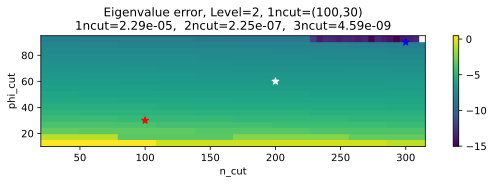

In [4]:
fig, ax = plt.subplots(figsize=(10, 2))
extent = [phi_grid_vec[0], phi_grid_vec[-1], ncut_vec[0], ncut_vec[-1]]
mat = np.log10(np.abs(eval_error))
cbar = ax.imshow(mat, extent=extent, origin='lower', aspect='equal')
plt.scatter(100, 30, color='red', s=50, marker='*', zorder=5)
plt.scatter(200, 60, color='white', s=50, marker='*', zorder=5)
plt.scatter(300, 90, color='blue', s=50, marker='*', zorder=5)

ax.set_title(f'Eigenvalue error, Level={level_index}, 1ncut=(100,30)'
             +f'\n1ncut={eval_error[xy_1ncut]:.3g}'
             +f',  2ncut={eval_error[xy_2ncut]:.3g}'
             +f',  3ncut={eval_error[xy_3ncut]:.3g}'
              )
ax.set_xlabel(r'n_cut' )
ax.set_ylabel(r'phi_cut')
# plt.colorbar()
# colorbar = fig.colorbar(cbar, cax=fig.add_axes([0.76, 0.15, 0.01, 0.7])) # [left, bottom, width, height]
colorbar = fig.colorbar(cbar) # [left, bottom, width, height]

In [5]:
qt.solver.Options?

Init signature:
qt.solver.Options(
    atol=1e-08,
    rtol=1e-06,
    method='adams',
    order=12,
    nsteps=1000,
    first_step=0,
    max_step=0,
    min_step=0,
    average_expect=True,
    average_states=False,
    tidy=True,
    num_cpus=0,
    norm_tol=0.001,
    norm_t_tol=1e-06,
    norm_steps=5,
    rhs_reuse=False,
    rhs_filename=None,
    ntraj=500,
    gui=False,
    rhs_with_state=False,
    store_final_state=False,
    store_states=False,
    steady_state_average=False,
    seeds=None,
    normalize_output=True,
    use_openmp=None,
    openmp_threads=None,
)
Docstring:     
Class of options for evolution solvers such as :func:`qutip.mesolve` and
:func:`qutip.mcsolve`. Options can be specified either as arguments to the
constructor::

    opts = Options(order=10, ...)

or by changing the class attributes after creation::

    opts = Options()
    opts.order = 10

Returns options class to be used as options in evolution solvers.

Attributes
----------

atol : float {

In [ ]:
drive_phi, drive_theta, truc = False, True, 30
# drive_phi, drive_theta, truc = True, False, 30
parallel = False
folder = 'data/data_xgate_theta.txt' if drive_theta else 'data/data_xgate_phi.txt'
f_xgate = pd.read_csv(folder)
params = f_xgate[['tg', 'drive_amp_1', 'drive_amp_2', 'detune_1', 'detune_2']].to_numpy()[:1]
n_cpu, n_job = 4, 4*len(params)
logi_state = [0, 2]
# [H0, drive_term, w_trans_1, w_trans_2, _] = ut.zero_pi_initialize(drive_phi, drive_theta, truncation=truc)
folder = f'data/data_one_zeropi_truncation=1000/'
evals = 2*np.pi* pd.read_csv(folder+ 'evals.txt').to_numpy().flatten()
n_theta = 2*np.pi* pd.read_csv(folder+ 'n_theta.txt').to_numpy()
n_phi = 2*np.pi* pd.read_csv(folder+ 'n_phi.txt').map(complex).to_numpy()
gate_target = qt.sigmax()
gamma2 =  1 / 1600e3
gammas =  1 / 2e3
gamma2_p = 0 / 100e3
# ratio = 10
# gammas =  gamma_2 * ratio
gammas_p = 1 / 9000

jump_t1   = []
jump_tphi = []
gamma_t1   = [0, gammas,  gamma2]  + [gammas]  * (truc-3)
gamma_tphi = [0, gammas_p, gamma2_p] + [gammas_p] * (truc-3)
for i in range(1,truc):
    jump_t1.append( np.sqrt(gamma_t1[i]) * qt.basis(truc,0) * qt.basis(truc,i).dag() )
    jump_tphi.append( np.sqrt(2*gamma_tphi[i]) * qt.basis(truc,i).proj() )

H0 = qt.Qobj(np.diag(evals))
if drive_phi:
    w_trans_1 = evals[9] - evals[0]
    w_trans_2 = evals[9] - evals[2]
    drive_term = n_phi
if drive_theta:
    w_trans_1 = evals[7] - evals[0]
    w_trans_2 = evals[7] - evals[2]
    drive_term = n_theta
hilbert_space = np.arange(truc).tolist()
H0_truc = ut.truncate_2(H0, hilbert_space)
drive_truc = ut.truncate_2(drive_term, hilbert_space)
H_qbt_drive = [H0_truc, [drive_truc, ut.drive_gauss_A],
                        [drive_truc, ut.drive_gauss_B],]
print('drive_phi=', drive_phi, '; drive_theta = ', drive_theta, '; truc = ', truc)
print('parallel = ', parallel)
print('params =')
for para in params:
    print(para.tolist(), ',')
print("n_cpu = ", n_cpu, ";   n_job = ", n_job)
print("gamma_2 = ", gamma2, "gamma_p2 = ", gamma2_p)
print("gammas = ", gammas, "gammas_p = ", gammas_p)
print(f"T1_2 = {1/gamma2} ns") if gamma2 != 0 else None
print(f"T1_other = {1/gammas} ns") if gammas != 0 else None
print(f"Tphi_2 = {1/gamma2_p} ns") if gamma2_p != 0 else None
print(f"Tphi_other = {1/gammas_p} ns") if gammas_p != 0 else None

############################################################

c_op_list = [qt.Qobj(np.zeros((truc, truc)))]
args = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
# f_ideal = [xgate_fidelity_log_noise(params[0], *args)]
f_ideal = Parallel(n_jobs=n_job, verbose=0)(delayed(xgate_fidelity_log_noise)(args_indep, *args)
                                            for args_indep in params)
print('\nf_ideal = [')
for i in range(0, len(f_ideal), 4):
    print(', '.join(map(str, f_ideal[i:i+4])), ',')
print(']')
print("Current Mountain Time:", datetime.now(pytz.timezone('America/Denver')))
############################################################
c_op_list = jump_t1 + jump_tphi
args = [H_qbt_drive, w_trans_1, w_trans_2, n_cpu, c_op_list, logi_state, parallel, gate_target]
f_noise = Parallel(n_jobs=n_job, verbose=0)(delayed(xgate_fidelity_log_noise)(args_indep, *args)
                                            for args_indep in params)
print('\nf_noise = [')
for i in range(0, len(f_noise), 4):
    print(', '.join(map(str, f_noise[i:i+4])), ',')
print(']')